In [3]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt


class Model:
    """Stochastic model constants."""
    THETA = 0.7
    MU = 1.5
    SIGMA = 0.06

In [9]:
def mu(y: float, _t: float) -> float:
    """Implement the Ornstein–Uhlenbeck mu."""
    return Model.THETA * (Model.MU - y)


def sigma(_y: float, _t: float) -> float:
    """Implement the Ornstein–Uhlenbeck sigma."""
    return Model.SIGMA


def dW(delta_t: float) -> float:
    """Sample a random number at each call."""
    return np.random.normal(loc=0.0, scale=np.sqrt(delta_t))


def run_simulation():
    """ Return the result of one full simulation."""
    T_INIT = 3
    T_END = 7
    N = 1000  # Compute at 1000 grid points
    DT = float(T_END - T_INIT) / N
    TS = np.arange(T_INIT, T_END + DT, DT)
    assert TS.size == N + 1

    Y_INIT = 0

    ys = np.zeros(TS.size)
    ys[0] = Y_INIT
    for i in range(1, TS.size):
        t = T_INIT + (i - 1) * DT
        y = ys[i - 1]
        ys[i] = y + mu(y, t) * DT + sigma(y, t) * dW(DT)

    return TS, ys


def plot_simulations(num_sims: int):
    """ Plot several simulations in one image."""
    for _ in range(num_sims):
        plt.plot(*run_simulation())

    plt.xlabel("time")
    plt.ylabel("y")
    plt.title("Ornstein-Uhlenbeck") 
    plt.show()

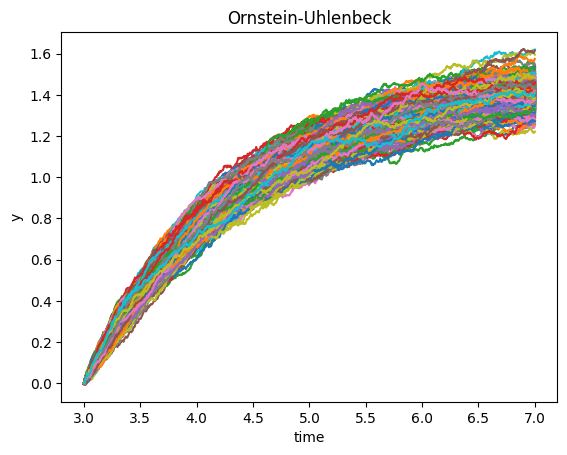

In [10]:
NUM_SIMS = 1000
plot_simulations(NUM_SIMS)

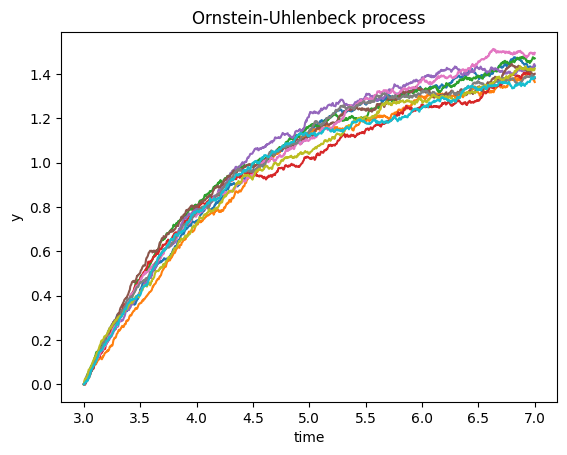

In [8]:
NUM_SIMS = 10
plot_simulations(NUM_SIMS)

E-M est une methode de resolution numérique des SDE (venant de  Leonhard Euler and Gisiro Maruyama)